In [1]:
import sys
sys.path.append('../')

from spicy_snow.retrieval import retrieve_snow_depth
from spicy_snow.find_data import get_sentinel1_urls, find_snowcover_urls
from spicy_snow.utils.download import download_urls
from spicy_snow.processing.generate_dataarrays import generate_sentinel1_dataarray, generate_snowcover_dataarray, generate_forest_fraction_dataarray, convert_snowcover_dates_to_s1_overpasses

import pandas as pd
from spicy_snow.utils.raster import tif_to_dataarray, combine_close_images, da_to01
from spicy_snow.utils.checks import validate_aoi, within_conus, validate_urls

import xarray as xr

In [2]:
test_start_date = '2020-10-01'
test_stop_date = '2021-05-01'
dates = [test_start_date, test_stop_date]
test_aoi = [-120, 40.5, -119.5,41]
aoi = test_aoi

In [ ]:
retrieval = retrieve_snow_depth(test_aoi, [test_start_date, test_stop_date], work_dir= '/Users/zmhoppinen/Documents/spicy-snow/local')

(spicy-snow spicy_snow.utils.spicy_logging INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-119.5000000000000000 40.5000000000000000, -119.5000000000000000 41.0000000000000000, -120.0000000000000000 41.0000000000000000, -120.0000000000000000 40.5000000000000000, -119.5000000000000000 40.5000000000000000))",
    "platform": [
        "SENTINEL-1A",
        "SENTINEL-1B",
        "SENTINEL-1C"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-05-01T00:00:00Z"
}
(spicy-snow spicy_snow.utils.spicy_logging INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow spicy_snow.utils.spicy_logging INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-119.5000000000000000 40.5000000000000000, -119.5000000000000000 41.0000000000000000, -120.0000000000000000 41.0000000000000000, -120.0000000000000000 40.5000000000000000, -119.5000000000000000 40.50

In [ ]:
from pathlib import Path
work_dir = Path('/Users/zmhoppinen/Documents/spicy-snow/local')
# get sentinel 1 data search results
s1_urls = get_sentinel1_urls(start_date = dates[0], stop_date = dates[1], aoi = aoi)


In [ ]:
s1_urls

['https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0.h5',
 'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0.iso.xml',
 'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0_VH.tif',
 'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0/OPERA_L2_RTC-S1_T064-135561-IW1_20210430T015146Z_20250903T203508Z_S1B_30_v1.0_VV.tif',
 'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPE

In [ ]:
download_urls_parallel(s1_urls, '/Users/zmhoppinen/Documents/spicy-snow/local/opera')

In [ ]:
from pathlib import Path
work_dir = Path('/Users/zmhoppinen/Documents/spicy-snow/local')
# get sentinel 1 data search results
s1_urls = get_sentinel1_urls(start_date = dates[0], stop_date = dates[1], aoi = aoi)
s1_fps = download_urls(s1_urls, work_dir.joinpath('opera'))

# generate dataset and start to save s1 data vars
ds = xr.Dataset()
ds['vv'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VV')

# grab spatial reference from first time step of VV
spatial_reference = ds['vv'].isel(time =0)

ds['vh'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VH', ref = spatial_reference)

# download viirs snow cover fraction for each sentinel 1 overpass date
snowcover_urls = find_snowcover_urls(date_list = ds.time.dt.date, aoi = aoi)
snowcover_fps = download_urls(snowcover_urls, work_dir.joinpath('snowcover'))

# generate snow cover dataset
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)

# resample date times from each day to the exact s1 overpass time. Doubles if two in one day
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])


(spicy-snow spicy_snow.utils.spicy_logging INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-119.5000000000000000 40.5000000000000000, -119.5000000000000000 41.0000000000000000, -120.0000000000000000 41.0000000000000000, -120.0000000000000000 40.5000000000000000, -119.5000000000000000 40.5000000000000000))",
    "platform": [
        "SENTINEL-1C",
        "SENTINEL-1A",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-01-11T00:00:00Z",
    "end": "2020-01-18T00:00:00Z"
}
(spicy-snow spicy_snow.utils.spicy_logging INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow spicy_snow.utils.spicy_logging INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-119.5000000000000000 40.5000000000000000, -119.5000000000000000 41.0000000000000000, -120.0000000000000000 41.0000000000000000, -120.0000000000000000 40.5000000000000000, -119.5000000000000000 40.50

(spicy-snow spicy_snow.utils.spicy_logging INFO) Granules found: 2
(spicy-snow spicy_snow.utils.spicy_logging INFO) Granules found: 2


In [ ]:
snowcover_urls = find_snowcover_urls(date_list = ds.time.dt.date, aoi = test_aoi)
snowcover_fps = download_urls(snowcover_urls, '/Users/zmhoppinen/Documents/spicy-snow/local/snowcover')
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])
# table 1 https://nsidc.org/sites/default/files/documents/user-guide/multi_vnp10a1f-v002-userguide.pdf
ds['watermask'] = (viirs_snowcover == 237).median('time')
ds['snowcover'] = viirs_snowcover.where(viirs_snowcover <= 100) > 10

KeyboardInterrupt: 

In [ ]:
ds['snowcover']

<xarray.DataArray 'snowcover' (time: 3, y: 1473, x: 1473)> Size: 7MB
array([[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True]],

       [[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True],
        [False, False, False, ...,  True,  True,  True]]],
      shape=(3, 1473, 1473))
Coordinates:
  * time         (time) datetime64[ns] 24B 2020-01-11T01:59:43.333332992 ... ...
  * y            (y) float64 12kB 41.0 41.0 41.0 41.0 ... 40.5 40.5 40.5 40.5
  * x            (x) float64 12kB -120.0 -120.0 -120.0 ... -119.5 -119.5 -119.5
    band         int64 8B 1
    spatial_ref  int64 8B 0
    track        (time) int64 24B 137 137 144
    platform     (time) <U3 36B 'S1B' 'S1A' 'S1A'

In [ ]:
ds['fcf'] = generate_forest_fraction_dataarray(test_aoi, ref = spatial_reference)

/Users/zmhoppinen/miniforge3/envs/spicy_testing/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


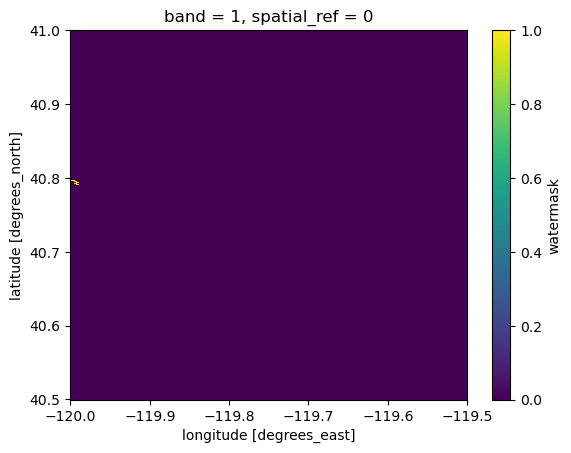

In [ ]:
ds['watermask'].median('time').plot()

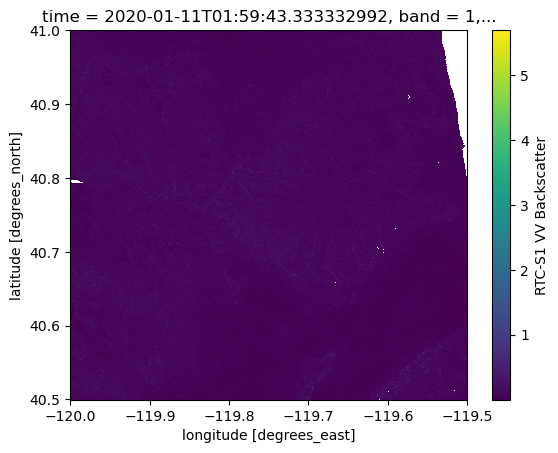

In [ ]:
ds['vv'].where(~ds['watermask'])[0].plot()